# Returns and Corporate-Action Forensics
## Experiment A: Synthetic 2-for-1 Stock Split

### Research question

**What breaks when an unadjusted stock split is treated as an ordinary market loss?**

A stock split changes the number of shares and the quoted price per share, but it does not change shareholder wealth. If the event is stored as a normal price decline, one false observation can contaminate returns, rolling risk estimates, anomaly detection, technical signals, and model inputs.

### Why start with synthetic data?

Real vendor data contain conventions, revisions, and timing ambiguities. Here, we construct the economic truth ourselves. Every discrepancy can therefore be attributed to our treatment of the split rather than to an undocumented vendor transformation.

### Learning objectives

By the end of the notebook, we will:

1. distinguish quoted price per share from investor wealth
2. derive raw and split-aware returns
3. measure how long one false return persists in rolling statistics
4. show how incompatible price units create false moving-average signals
5. trace one corporate-action error through a regression pipeline
6. demonstrate why robust preprocessing cannot repair an incorrect economic label

## Notation

- $g_t$: latent economic log return over $(t-1,t]$;
- $W_t$: investor wealth;
- $q_t$: number of shares held;
- $P_t^{\mathrm{raw}}$: raw quoted price per share;
- $s_t$: event split ratio;
- $r_t^{\mathrm{raw}}$: return calculated from raw prices;
- $r_t^{\mathrm{split}}$: split-aware economic return.

The split occurs at Python index `30`, the 31st observation.

# 1. Reproducible setup

 This section:

- locates the project root without assuming where Jupyter was launched
- imports the tested return functions from `src/`
- records all experiment parameters in one place
- fixes the random seed at `1108`

`pandas.bdate_range` generates weekdays rather than an exchange-specific calendar. That simplification is appropriate because this experiment studies accounting identities, not actual exchange sessions.

In [198]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler


def find_project_root(start: Path) -> Path:
    """Find the nearest parent directory containing pyproject.toml."""
    resolved_start = start.resolve()

    for candidate in (resolved_start, *resolved_start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing pyproject.toml."
    )


project_root = find_project_root(Path.cwd())
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from returns_forensics.returns import (
    log_returns,
    simple_returns,
    split_aware_returns,
)

synthetic_output_path = (
    project_root
    / "data"
    / "raw"
    / "synthetic"
    / "synthetic_split.csv"
)

table_dir = project_root / "reports" / "tables"
figure_dir = project_root / "reports" / "figures"

table_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

In [199]:
SEED = 1108
N_DAYS = 60
START_DATE = "2024-01-02"

INITIAL_WEALTH = 100.0
INITIAL_SHARES = 1.0
DAILY_LOG_RETURN_STD = 0.01

SPLIT_INDEX = 30
SPLIT_RATIO = 2.0
EVENT_ROWS = [SPLIT_INDEX, SPLIT_INDEX + 1]

ROLLING_WINDOW = 20
FAST_MA_WINDOW = 5
SLOW_MA_WINDOW = 10

RIDGE_LAMBDA = 1.0

# 2. Construct the synthetic economic data

We must separate two objects:

1. **Economic wealth**, which should not jump because of a pure split.
2. **Raw quoted price per share**, whose numerical unit changes when the share count changes.

We generate latent economic log returns

$$
g_t\sim\mathcal N(0,\sigma^2)
$$

and define wealth by

$$
W_t=W_0\exp\left(\sum_{j=0}^{t}g_j\right).
$$

We set $g_0=0$ because the first observation has no preceding interval. We also set the split-date economic return to zero, ensuring that any apparent loss on that date is purely mechanical.

For a 2-for-1 split,

$$
q_t=
\begin{cases}
1,&t<t_s,\\
2,&t\ge t_s,
\end{cases}
\qquad
P_t^{\mathrm{raw}}=\frac{W_t}{q_t}.
$$

Therefore,

$$
q_tP_t^{\mathrm{raw}}=W_t.
$$

In [200]:
dates = pd.bdate_range(start=START_DATE, periods=N_DAYS, name="date",)

rng = np.random.default_rng(seed=SEED)
latent_log_return = rng.normal(loc=0.0, scale=DAILY_LOG_RETURN_STD, size=N_DAYS,)

latent_log_return[0] = 0.0

latent_log_return[SPLIT_INDEX] = 0.0

split_ratio = np.ones(N_DAYS)
split_ratio[SPLIT_INDEX] = SPLIT_RATIO

shares_held = np.full(N_DAYS, INITIAL_SHARES)
shares_held[SPLIT_INDEX:] *= SPLIT_RATIO

investor_wealth = INITIAL_WEALTH * np.exp(np.cumsum(latent_log_return))
raw_price = investor_wealth / shares_held

base_columns = [
    "date",
    "latent_log_return",
    "shares_held",
    "raw_price",
    "investor_wealth",
    "split_ratio",
]

df = pd.DataFrame(
    {
        "date": dates,
        "latent_log_return": latent_log_return,
        "shares_held": shares_held,
        "raw_price": raw_price,
        "investor_wealth": investor_wealth,
        "split_ratio": split_ratio,
    }
)

display(df.loc[28:32, base_columns])

,date,latent_log_return,shares_held,raw_price,investor_wealth,split_ratio
28,2024-02-09,0.000336,1.0,96.546640,96.546640,1.0
29,2024-02-12,-0.004581,1.0,96.105358,96.105358,1.0
30,2024-02-13,0.000000,2.0,48.052679,96.105358,2.0
31,2024-02-14,0.007395,2.0,48.409326,96.818652,1.0
32,2024-02-15,-0.010041,2.0,47.925695,95.851390,1.0


These checks encode the facts that matter economically:

- raw prices remain positive
- wealth equals shares times raw price
- shares double on the split date
- raw price halves on the split date
- wealth is unchanged by the split itself

We use tolerance-based comparisons because floating-point arithmetic is not exact.

In [201]:
assert (df["raw_price"] > 0).all()

np.testing.assert_allclose(
    df["shares_held"] * df["raw_price"],
    df["investor_wealth"],
)

shares_ratio = df.loc[SPLIT_INDEX, "shares_held"] / df.loc[SPLIT_INDEX - 1, "shares_held"]

price_ratio = df.loc[SPLIT_INDEX, "raw_price"] / df.loc[SPLIT_INDEX - 1, "raw_price"]

wealth_ratio = df.loc[SPLIT_INDEX, "investor_wealth"] / df.loc[SPLIT_INDEX - 1, "investor_wealth"]

np.testing.assert_allclose(shares_ratio, SPLIT_RATIO)
np.testing.assert_allclose(price_ratio, 1.0 / SPLIT_RATIO)
np.testing.assert_allclose(wealth_ratio, 1.0)

display(
    pd.Series(
        {
            "Shares ratio at split": shares_ratio,
            "Raw-price ratio at split": price_ratio,
            "Wealth ratio at split": wealth_ratio,
        }
    ).to_frame("value")
)

,value
Shares ratio at split,2.0
Raw-price ratio at split,0.5
Wealth ratio at split,1.0


The raw file stores only the source observations and event fields. Returns, rolling statistics, signals, and model outputs remain reproducible derived artifacts rather than being mixed into the raw-data layer.

In [202]:
synthetic_output_path.parent.mkdir(parents=True, exist_ok=True)
df[base_columns].to_csv(synthetic_output_path, index=False)

# 3. Reconcile raw and split-aware returns

A price series is not automatically a wealth series. Across the split, the raw series changes from the price of one old share to the price of one new share.

The raw simple return is

$$
r_t^{\mathrm{raw}}
=
\frac{P_t^{\mathrm{raw}}}{P_{t-1}^{\mathrm{raw}}}-1.
$$

The raw log return is

$$
g_t^{\mathrm{raw}}
=
\log P_t^{\mathrm{raw}}-\log P_{t-1}^{\mathrm{raw}}.
$$

The split-aware return is

$$
r_t^{\mathrm{split}}
=
\frac{s_tP_t^{\mathrm{raw}}}{P_{t-1}^{\mathrm{raw}}}-1.
$$

We compare it with the direct wealth return

$$
r_t^W=\frac{W_t}{W_{t-1}}-1.
$$

If the corporate action is handled correctly, $r_t^{\mathrm{split}}=r_t^W$.

In [203]:
df["raw_simple_return"] = simple_returns(df["raw_price"])
df["raw_log_return"] = log_returns(df["raw_price"])

df["split_aware_return"] = split_aware_returns(raw_prices=df["raw_price"], split_ratios=df["split_ratio"],)

df["wealth_return"] = df["investor_wealth"]/ df["investor_wealth"].shift(1) - 1.0

return_columns = [
    "date",
    "raw_price",
    "shares_held",
    "raw_simple_return",
    "raw_log_return",
    "split_aware_return",
    "wealth_return",
]

display(
    df.loc[28:32, return_columns].style.format(
        {
            "raw_price": "${:.4f}",
            "shares_held": "{:.1f}",
            "raw_simple_return": "{:.3f}",
            "raw_log_return": "{:.6f}",
            "split_aware_return": "{:.3%}",
            "wealth_return": "{:.3%}",
        }
    )
)

,date,raw_price,shares_held,raw_simple_return,raw_log_return,split_aware_return,wealth_return
28,2024-02-09 00:00:00,$96.5466,1.0,0.000,0.000336,0.034%,0.034%
29,2024-02-12 00:00:00,$96.1054,1.0,-0.005,-0.004581,-0.457%,-0.457%
30,2024-02-13 00:00:00,$48.0527,2.0,-0.500,-0.693147,0.000%,0.000%
31,2024-02-14 00:00:00,$48.4093,2.0,0.007,0.007395,0.742%,0.742%
32,2024-02-15 00:00:00,$47.9257,2.0,-0.010,-0.010041,-0.999%,-0.999%


In [204]:
np.testing.assert_allclose(
    df.loc[SPLIT_INDEX, "raw_simple_return"],
    -0.5,
)
np.testing.assert_allclose(
    df.loc[SPLIT_INDEX, "raw_log_return"],
    np.log(0.5),
)
np.testing.assert_allclose(
    df.loc[SPLIT_INDEX, "split_aware_return"],
    0.0,
)
np.testing.assert_allclose(
    df.loc[SPLIT_INDEX, "wealth_return"],
    0.0,
)

np.testing.assert_allclose(
    np.expm1(df["raw_log_return"]),
    df["raw_simple_return"],
)

np.testing.assert_allclose(
    df["split_aware_return"],
    df["wealth_return"],
)

### Result

The raw series reports a $-50\%$ price return even though investor wealth is unchanged. This is not simply an unusually large market observation, it is an incorrectly measured economic label.

# 4. Verify cumulative wealth


Correct one-period returns must reconstruct the same cumulative wealth path as direct economic accounting:

$$
C_t=\prod_{j=1}^{t}(1+r_j),
\qquad
C_t=\frac{W_t}{W_0}.
$$

This checks the entire return path rather than only the event date.

In [205]:
df["cumulative_growth_factor"] = (1.0 + df["split_aware_return"].fillna(0.0)).cumprod()

normalized_wealth = df["investor_wealth"] / df["investor_wealth"].iloc[0]

np.testing.assert_allclose(
    df["cumulative_growth_factor"],
    normalized_wealth,
)

display(
    pd.Series(
        {
            "Final compounded growth factor": (
                df["cumulative_growth_factor"].iloc[-1]
            ),
            "Final wealth ratio": normalized_wealth.iloc[-1],
        }
    ).to_frame("value")
)

,value
Final compounded growth factor,0.895627
Final wealth ratio,0.895627


# 5. Measure rolling-statistic contamination

One false observation can affect many later estimates because rolling windows retain it until it ages out. We study two diagnostics:

1. contemporaneous rolling volatility;
2. ex-ante rolling z-scores.

## Rolling volatility

For a 20-return sample,

$$
\widehat{\sigma}_{t,20}
=
\sqrt{
\frac{1}{19}
\sum_{j=t-19}^{t}
(r_j-\bar r_{t,20})^2
}.
$$

Define the distortion ratio

$$
D_t=
\frac{\widehat{\sigma}_{t,20}^{\mathrm{raw}}}
{\widehat{\sigma}_{t,20}^{\mathrm{split}}}.
$$

The split return at index 30 remains inside this 20-return window through index 49. At index 50, it leaves the window.

In [206]:
df["raw_volatility_20d"] = df["raw_simple_return"].rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW,).std(ddof=1)

df["split_aware_volatility_20d"] = df["split_aware_return"].rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW,).std(ddof=1)

df["volatility_distortion_ratio"] = df["raw_volatility_20d"] / df["split_aware_volatility_20d"]

peak_distortion_index = df["volatility_distortion_ratio"].idxmax()

peak_distortion = df.loc[peak_distortion_index, "volatility_distortion_ratio",]

In [207]:
np.testing.assert_allclose(
    df.loc[29, "raw_volatility_20d"],
    df.loc[29, "split_aware_volatility_20d"],
)

assert (
    df.loc[30, "raw_volatility_20d"]
    > df.loc[30, "split_aware_volatility_20d"]
)
assert (
    df.loc[49, "raw_volatility_20d"]
    > df.loc[49, "split_aware_volatility_20d"]
)

np.testing.assert_allclose(
    df.loc[50, "raw_volatility_20d"],
    df.loc[50, "split_aware_volatility_20d"],
)

assert peak_distortion > 5.0

volatility_columns = [
    "date",
    "raw_volatility_20d",
    "split_aware_volatility_20d",
    "volatility_distortion_ratio",
]

display(
    df.loc[[29, 30, 31, 49, 50], volatility_columns].style.format(
        {
            "raw_volatility_20d": "{:.3%}",
            "split_aware_volatility_20d": "{:.3%}",
            "volatility_distortion_ratio": "{:.2f}×",
        }
    )
)

print(
    f"Peak distortion: {peak_distortion:.2f}× "
    f"at source index {peak_distortion_index}."
)

,date,raw_volatility_20d,split_aware_volatility_20d,volatility_distortion_ratio
29,2024-02-12 00:00:00,1.079%,1.079%,1.00×
30,2024-02-13 00:00:00,11.186%,1.079%,10.37×
31,2024-02-14 00:00:00,11.201%,1.098%,10.20×
49,2024-03-11 00:00:00,11.218%,1.187%,9.45×
50,2024-03-12 00:00:00,1.188%,1.188%,1.00×


Peak distortion: 13.63× at source index 41.


### Result

One observation inflates approximately 20 consecutive risk estimates. A volatility-targeted system could therefore reduce exposure or trigger risk controls long after the split date.

## Ex-ante z-scores

The current return must be judged against information available before it occurred. Including the current observation in its own reference distribution would let an extreme value inflate its own denominator.

Using the preceding 20 returns,

$$
\widehat{\mu}_{t-1,20}
=
\frac{1}{20}\sum_{j=t-20}^{t-1}r_j,
$$

$$
\widehat{\sigma}_{t-1,20}
=
\sqrt{
\frac{1}{19}
\sum_{j=t-20}^{t-1}
(r_j-\widehat{\mu}_{t-1,20})^2
},
$$

$$
z_t=
\frac{r_t-\widehat{\mu}_{t-1,20}}
{\widehat{\sigma}_{t-1,20}}.
$$

The `.shift(1)` below enforces this chronology.

In [208]:
df["raw_return_mean_20d"] = df["raw_simple_return"].rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW,) .mean().shift(1)

df["raw_return_std_20d"] = df["raw_simple_return"].rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW,) .std(ddof=1).shift(1)

df["raw_return_zscore_20d"] = (df["raw_simple_return"] - df["raw_return_mean_20d"]) / df["raw_return_std_20d"]


df["split_aware_return_mean_20d"] = df["split_aware_return"].rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW,).mean().shift(1)

df["split_aware_return_std_20d"] = df["split_aware_return"].rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW, ).std(ddof=1).shift(1)

df["split_aware_return_zscore_20d"] = ( df["split_aware_return"] - df["split_aware_return_mean_20d"]) / df["split_aware_return_std_20d"]

In [209]:
np.testing.assert_allclose(
    df.loc[SPLIT_INDEX, "raw_return_mean_20d"],
    df.loc[SPLIT_INDEX, "split_aware_return_mean_20d"],
)
np.testing.assert_allclose(
    df.loc[SPLIT_INDEX, "raw_return_std_20d"],
    df.loc[SPLIT_INDEX, "split_aware_return_std_20d"],
)

assert df.loc[SPLIT_INDEX, "raw_return_zscore_20d"] < -20.0
assert abs(
    df.loc[SPLIT_INDEX, "split_aware_return_zscore_20d"]
) < 1.0

assert (
    df.loc[31, "raw_return_std_20d"]
    > df.loc[31, "split_aware_return_std_20d"]
)
assert (
    df.loc[50, "raw_return_std_20d"]
    > df.loc[50, "split_aware_return_std_20d"]
)

np.testing.assert_allclose(
    df.loc[51, "raw_return_zscore_20d"],
    df.loc[51, "split_aware_return_zscore_20d"],
)

zscore_columns = [
    "date",
    "raw_simple_return",
    "split_aware_return",
    "raw_return_zscore_20d",
    "split_aware_return_zscore_20d",
]

display(
    df.loc[[29, 30, 31, 50, 51], zscore_columns].style.format(
        {
            "raw_simple_return": "{:.3%}",
            "split_aware_return": "{:.3%}",
            "raw_return_zscore_20d": "{:.2f}",
            "split_aware_return_zscore_20d": "{:.2f}",
        }
    )
)

,date,raw_simple_return,split_aware_return,raw_return_zscore_20d,split_aware_return_zscore_20d
29,2024-02-12 00:00:00,-0.457%,-0.457%,-0.25,-0.25
30,2024-02-13 00:00:00,-50.000%,0.000%,-46.17,0.19
31,2024-02-14 00:00:00,0.742%,0.742%,0.31,0.87
50,2024-03-12 00:00:00,0.189%,0.189%,0.25,0.25
51,2024-03-13 00:00:00,0.785%,0.785%,0.74,0.74


### Result

The raw series labels a bookkeeping event as an extreme market anomaly. It then carries the false observation into future reference windows, changing how later ordinary returns are standardized.

# 6. Diagnose moving-average unit contamination

Moving averages assume comparable units. Raw prices before and after a split violate that assumption:

- before the split: price per old share;
- after the split: price per new share.

Define a continuous analytical price on the original-share basis:

$$
P_t^{\mathrm{adj}}
=
\frac{q_tP_t^{\mathrm{raw}}}{q_0}.
$$

Because $q_0=1$,

$$
P_t^{\mathrm{adj}}=W_t.
$$

For a series $X_t$,

$$
M_{t,k}(X)=\frac{1}{k}\sum_{j=t-k+1}^{t}X_j.
$$

The diagnostic signal is

$$
S_t(X)=
\mathbf 1\{M_{t,5}(X)>M_{t,10}(X)\}.
$$

In [210]:
df["split_adjusted_price"] = df["shares_held"]* df["raw_price"]/ df.loc[0, "shares_held"]


df["raw_fast_ma_5d"] = df["raw_price"].rolling(window=FAST_MA_WINDOW, min_periods=FAST_MA_WINDOW,).mean()

df["adjusted_fast_ma_5d"] = df["split_adjusted_price"].rolling(window=FAST_MA_WINDOW, min_periods=FAST_MA_WINDOW,).mean()


df["raw_slow_ma_10d"] = df["raw_price"].rolling(window=SLOW_MA_WINDOW, min_periods=SLOW_MA_WINDOW,).mean()

df["adjusted_slow_ma_10d"] = df["split_adjusted_price"].rolling(window=SLOW_MA_WINDOW, min_periods=SLOW_MA_WINDOW,).mean()


df["raw_ma_signal"] = df["raw_fast_ma_5d"].gt(df["raw_slow_ma_10d"]).where(df["raw_slow_ma_10d"].notna()).astype("Int64")

df["adjusted_ma_signal"] = df["adjusted_fast_ma_5d"].gt(df["adjusted_slow_ma_10d"]).where(df["adjusted_slow_ma_10d"].notna()).astype("Int64")


df["ma_signal_disagreement"] = df["raw_ma_signal"].ne(df["adjusted_ma_signal"])& df["raw_ma_signal"].notna()& df["adjusted_ma_signal"].notna()


In [211]:
np.testing.assert_allclose(
    df["split_adjusted_price"],
    df["investor_wealth"],
)
np.testing.assert_allclose(
    df.loc[: SPLIT_INDEX - 1, "raw_price"],
    df.loc[: SPLIT_INDEX - 1, "split_adjusted_price"],
)

assert df.loc[:8, "raw_ma_signal"].isna().all()
assert df.loc[:8, "adjusted_ma_signal"].isna().all()

disagreement_indices = df.index[
    df["ma_signal_disagreement"]
].tolist()

assert disagreement_indices == [36, 37, 38]

for idx in disagreement_indices:
    assert df.loc[idx, "raw_ma_signal"] == 0
    assert df.loc[idx, "adjusted_ma_signal"] == 1

assert (
    df.loc[39, "raw_ma_signal"]
    == df.loc[39, "adjusted_ma_signal"]
)

ma_columns = [
    "date",
    "raw_price",
    "split_adjusted_price",
    "raw_slow_ma_10d",
    "adjusted_slow_ma_10d",
    "raw_ma_signal",
    "adjusted_ma_signal",
    "ma_signal_disagreement",
]

display(
    df.loc[34:40, ma_columns].style.format(
        {
            "raw_price": "${:.4f}",
            "split_adjusted_price": "${:.4f}",
            "raw_slow_ma_10d": "${:.4f}",
            "adjusted_slow_ma_10d": "${:.4f}",
        }
    )
)

,date,raw_price,split_adjusted_price,raw_slow_ma_10d,adjusted_slow_ma_10d,raw_ma_signal,adjusted_ma_signal,ma_signal_disagreement
34,2024-02-19 00:00:00,$48.6881,$97.3763,$72.7623,$96.8933,0,0,False
35,2024-02-20 00:00:00,$48.3720,$96.7439,$67.6888,$96.6570,0,0,False
36,2024-02-21 00:00:00,$48.2268,$96.4536,$62.7075,$96.4985,0,1,True
37,2024-02-22 00:00:00,$48.7520,$97.5039,$57.9313,$96.5974,0,1,True
38,2024-02-23 00:00:00,$47.9526,$95.9053,$53.0719,$96.5333,0,1,True
39,2024-02-26 00:00:00,$48.0725,$96.1449,$48.2686,$96.5372,1,1,False
40,2024-02-27 00:00:00,$47.8890,$95.7781,$48.2523,$96.5045,0,0,False


### Result

At indices $36,37,38$, the raw signal is bearish while the action-aware signal is bullish. The raw 10-day average still mixes pre-split prices near \$96 with post-split prices near \$48.

By index 39, the raw 10-day window contains only post-split observations, so the unit mismatch disappears.

# 7. Construct the supervised-learning sample

## Motivation

For the model

$$
r_t=a+\beta r_{t-1}+\varepsilon_t,
$$

we define

$$
x_t=r_{t-1},
\qquad
y_t=r_t.
$$

The symbol $a$ denotes the regression intercept. Later, scikit-learn's argument `Ridge(alpha=...)` will correspond to the mathematical penalty parameter $\lambda$, not to this intercept.

The false split return appears twice:

1. as the target at source index 30;
2. as the lagged feature at source index 31.

Thus one corporate-action error corrupts two supervised rows before any scaler or regression is fitted.

In [212]:
df["raw_lag1_return"] = df["raw_simple_return"].shift(1)
df["raw_next_return_target"] = df["raw_simple_return"]

df["aware_lag1_return"] = df["split_aware_return"].shift(1)
df["aware_next_return_target"] = df["split_aware_return"]

raw_model_data = (
    df[
        [
            "date",
            "raw_lag1_return",
            "raw_next_return_target",
        ]
    ]
    .dropna()
    .reset_index(names="source_index")
)

aware_model_data = (
    df[
        [
            "date",
            "aware_lag1_return",
            "aware_next_return_target",
        ]
    ]
    .dropna()
    .reset_index(names="source_index")
)

raw_model_data["split_in_feature"] = raw_model_data["source_index"] == SPLIT_INDEX + 1
raw_model_data["split_in_target"] = raw_model_data["source_index"] == SPLIT_INDEX
raw_model_data["corporate_action_contaminated"] = raw_model_data["split_in_feature"]| raw_model_data["split_in_target"]

In [213]:
assert len(raw_model_data) == len(aware_model_data)

pd.testing.assert_series_equal(
    raw_model_data["source_index"],
    aware_model_data["source_index"],
    check_names=False,
)
pd.testing.assert_series_equal(
    raw_model_data["date"],
    aware_model_data["date"],
    check_names=False,
)

contaminated_source_indices = raw_model_data.loc[
    raw_model_data["corporate_action_contaminated"],
    "source_index",
].tolist()

assert contaminated_source_indices == EVENT_ROWS

raw_target_at_split = raw_model_data.loc[
    raw_model_data["source_index"] == SPLIT_INDEX,
    "raw_next_return_target",
].iloc[0]
aware_target_at_split = aware_model_data.loc[
    aware_model_data["source_index"] == SPLIT_INDEX,
    "aware_next_return_target",
].iloc[0]

np.testing.assert_allclose(raw_target_at_split, -0.5)
np.testing.assert_allclose(aware_target_at_split, 0.0)

raw_feature_after_split = raw_model_data.loc[
    raw_model_data["source_index"] == SPLIT_INDEX + 1,
    "raw_lag1_return",
].iloc[0]
aware_feature_after_split = aware_model_data.loc[
    aware_model_data["source_index"] == SPLIT_INDEX + 1,
    "aware_lag1_return",
].iloc[0]

np.testing.assert_allclose(raw_feature_after_split, -0.5)
np.testing.assert_allclose(aware_feature_after_split, 0.0)

uncontaminated = ~raw_model_data["source_index"].isin(EVENT_ROWS)

np.testing.assert_allclose(
    raw_model_data.loc[
        uncontaminated,
        ["raw_lag1_return", "raw_next_return_target"],
    ].to_numpy(),
    aware_model_data.loc[
        uncontaminated,
        ["aware_lag1_return", "aware_next_return_target"],
    ].to_numpy(),
)

In [214]:
model_comparison = raw_model_data.merge(aware_model_data, on=["source_index", "date"], validate="one_to_one",)

model_comparison["role"] = "ordinary"
model_comparison.loc[model_comparison["source_index"] == SPLIT_INDEX,"role",] = "split in target"
model_comparison.loc[ model_comparison["source_index"] == SPLIT_INDEX + 1, "role",] = "split in feature"

model_display_columns = [
    "source_index",
    "date",
    "role",
    "raw_lag1_return",
    "aware_lag1_return",
    "raw_next_return_target",
    "aware_next_return_target",
]

display(
    model_comparison.loc[
        model_comparison["source_index"].between(29, 32),
        model_display_columns,
    ].style.format(
        {
            "raw_lag1_return": "{:.3%}",
            "aware_lag1_return": "{:.3%}",
            "raw_next_return_target": "{:.3%}",
            "aware_next_return_target": "{:.3%}",
        }
    )
)

,source_index,date,role,raw_lag1_return,aware_lag1_return,raw_next_return_target,aware_next_return_target
27,29,2024-02-12 00:00:00,ordinary,0.034%,0.034%,-0.457%,-0.457%
28,30,2024-02-13 00:00:00,split in target,-0.457%,-0.457%,-50.000%,0.000%
29,31,2024-02-14 00:00:00,split in feature,-50.000%,0.000%,0.742%,0.742%
30,32,2024-02-15 00:00:00,ordinary,0.742%,0.742%,-0.999%,-0.999%


### Result

The split creates two different errors:

- **target contamination:** an ordinary previous return appears to be followed by a $-50\%$ economic loss
- **feature contamination:** the next row presents $-50\%$ as an observed predictor

A scaler fitted to the raw feature changes the transformation of every observation. More fundamentally, no feature transformation can reinterpret a false target as a correct investor return.

# 8. Quantify model contamination

We now use identical Ridge pipelines to isolate four questions:

1. How much do the scaler and fitted model change?
2. Where is the residual loss concentrated?
3. Do the models become identical when the two event rows are removed before fitting?
4. Can robust feature scaling repair the contaminated dataset?

## Model specification and reusable diagnostics


`StandardScaler` transforms the feature using

$$
z_i=\frac{x_i-\bar x}{s_x}.
$$

The fitted Ridge model minimizes

$$
\sum_{i=1}^{n}
\left(y_i-a-bz_i\right)^2
+
\lambda b^2,
$$

where $\lambda=1$. In scikit-learn, this penalty is passed as `Ridge(alpha=1.0)`. If

$$
\widehat y=a+b\frac{x-c}{s},
$$

then the coefficient in original return units is

$$
\beta_{\mathrm{original}}=\frac{b}{s},
$$

and the original-unit intercept is

$$
a_{\mathrm{original}}=a-\frac{bc}{s}.
$$

The helper below returns the fitted pipeline, predictions, residuals, and all diagnostics from one fit, preventing accidental refits with different specifications.

In [215]:
def fit_ridge_diagnostics(X: pd.DataFrame, y: pd.Series, scaler,) -> dict:
    """Fit one Ridge pipeline and return reusable diagnostics."""
    pipeline = Pipeline([("scaler", scaler), ("ridge", Ridge(alpha=RIDGE_LAMBDA)),])
    pipeline.fit(X, y)

    predictions = pd.Series(
        pipeline.predict(X),
        index=y.index,
        name="prediction",
    )
    residuals = y - predictions

    fitted_scaler = pipeline.named_steps["scaler"]
    fitted_ridge = pipeline.named_steps["ridge"]

    if isinstance(fitted_scaler, StandardScaler):
        center_value = fitted_scaler.mean_[0]
        center_statistic = "mean"
        scale_statistic = "standard deviation"
    elif isinstance(fitted_scaler, RobustScaler):
        center_value = fitted_scaler.center_[0]
        center_statistic = "median"
        scale_statistic = "interquartile range"
    else:
        raise TypeError(
            f"Unsupported scaler type: {type(fitted_scaler).__name__}"
        )

    scale_value = fitted_scaler.scale_[0]
    coefficient_scaled = fitted_ridge.coef_[0]
    coefficient_original = coefficient_scaled / scale_value
    intercept_scaled = fitted_ridge.intercept_
    intercept_original = (
        intercept_scaled
        - coefficient_scaled * center_value / scale_value
    )

    metrics = {
        "n_samples": len(y),
        "center_statistic": center_statistic,
        "center_value": center_value,
        "scale_statistic": scale_statistic,
        "scale_value": scale_value,
        "ridge_intercept_scaled": intercept_scaled,
        "ridge_intercept_original_units": intercept_original,
        "ridge_coefficient_scaled": coefficient_scaled,
        "ridge_coefficient_original_units": coefficient_original,
        "rmse": np.sqrt(mean_squared_error(y, predictions)),
        "mae": mean_absolute_error(y, predictions),
        "maximum_absolute_residual": residuals.abs().max(),
        "r_squared": r2_score(y, predictions),
    }

    return {
        "pipeline": pipeline,
        "predictions": predictions,
        "residuals": residuals,
        "metrics": metrics,
    }


X_raw = raw_model_data[["raw_lag1_return"]]
y_raw = raw_model_data["raw_next_return_target"]

X_aware = aware_model_data[["aware_lag1_return"]]
y_aware = aware_model_data["aware_next_return_target"]

## Standardized Ridge comparison

*Question:* How much does the unadjusted split alter preprocessing, fitted parameters, and in-sample residual loss?

In [216]:
raw_standard_result = fit_ridge_diagnostics(X_raw, y_raw, StandardScaler(),)
aware_standard_result = fit_ridge_diagnostics(X_aware, y_aware, StandardScaler(),)

standard_comparison = pd.DataFrame(
    {
        "raw": raw_standard_result["metrics"],
        "split_aware": aware_standard_result["metrics"],
    }
).T

standard_display_columns = [
    "center_value",
    "scale_value",
    "ridge_intercept_original_units",
    "ridge_coefficient_original_units",
    "rmse",
    "mae",
    "maximum_absolute_residual",
    "r_squared",
]

display(
    standard_comparison[standard_display_columns].style.format(
        {
            "center_value": "{:.3%}",
            "scale_value": "{:.3%}",
            "ridge_intercept_original_units": "{:.3%}",
            "ridge_coefficient_original_units": "{:.5f}",
            "rmse": "{:.3%}",
            "mae": "{:.3%}",
            "maximum_absolute_residual": "{:.3%}",
            "r_squared": "{:.5f}",
        }
    )
)

,center_value,scale_value,ridge_intercept_original_units,ridge_coefficient_original_units,rmse,mae,maximum_absolute_residual,r_squared
raw,-1.025%,6.569%,-1.046%,-0.02949,6.565%,1.936%,48.968%,0.00090
split_aware,-0.162%,1.033%,-0.158%,-0.03040,1.020%,0.814%,3.063%,0.00098


In [217]:
assert raw_standard_result["metrics"]["n_samples"] == (
    aware_standard_result["metrics"]["n_samples"]
)

assert np.isfinite(
    standard_comparison[
        standard_display_columns
    ].to_numpy(dtype=float)
).all()

assert (
    standard_comparison.loc["raw", "scale_value"]
    > 5 * standard_comparison.loc["split_aware", "scale_value"]
)
assert (
    standard_comparison.loc["raw", "rmse"]
    > 5 * standard_comparison.loc["split_aware", "rmse"]
)
assert (
    standard_comparison.loc["raw", "maximum_absolute_residual"]
    > standard_comparison.loc[
        "split_aware",
        "maximum_absolute_residual",
    ]
)
assert standard_comparison.loc["split_aware", "rmse"] < 0.02

model_distortion_ratios = pd.Series(
    {
        "Feature-scale inflation": (
            standard_comparison.loc["raw", "scale_value"]
            / standard_comparison.loc["split_aware", "scale_value"]
        ),
        "RMSE inflation": (
            standard_comparison.loc["raw", "rmse"]
            / standard_comparison.loc["split_aware", "rmse"]
        ),
        "MAE inflation": (
            standard_comparison.loc["raw", "mae"]
            / standard_comparison.loc["split_aware", "mae"]
        ),
        "Maximum-residual inflation": (
            standard_comparison.loc[
                "raw",
                "maximum_absolute_residual",
            ]
            / standard_comparison.loc[
                "split_aware",
                "maximum_absolute_residual",
            ]
        ),
    }
)

display(model_distortion_ratios.to_frame("ratio").style.format("{:.2f}×"))

,ratio
Feature-scale inflation,6.36×
RMSE inflation,6.44×
MAE inflation,2.38×
Maximum-residual inflation,15.99×


### Result

The raw split inflates the feature scale and residual loss. The original-unit slopes can remain similar because the standardized coefficient and scaler denominator adjust together. This illustrates why no single model parameter is a sufficient contamination diagnostic.

The near-zero $R^2$ values are not a failure of the experiment. The purpose is to compare data representations, not to establish predictability.

## Residual attribution

Aggregate RMSE tells us that the raw model is worse, but not where the error originates. We decompose squared and absolute error into:

- the two event-adjacent rows $C=\{30,31\}$
- all remaining ordinary rows

For residual $e_i=y_i-\widehat y_i$,

$$
\text{event SSE share}
=
\frac{\sum_{i\in C}e_i^2}
{\sum_i e_i^2}.
$$

The event-excluded RMSE is

$$
\operatorname{RMSE}_{-C}
=
\sqrt{
\frac{\sum_{i\notin C}e_i^2}
{n-|C|}
}.
$$

This distinguishes direct loss concentration from parameter contamination that propagates to ordinary rows.

In [218]:
def attach_residual_diagnostics(model_data: pd.DataFrame, result: dict,) -> pd.DataFrame:
    """Attach predictions and row-level errors from an existing fit."""
    output = model_data.copy()
    output["prediction"] = result["predictions"].to_numpy()
    output["residual"] = result["residuals"].to_numpy()
    output["squared_error"] = output["residual"] ** 2
    output["absolute_error"] = output["residual"].abs()
    output["event_adjacent"] = output["source_index"].isin(EVENT_ROWS)
    return output


def calculate_residual_attribution( model_data: pd.DataFrame,) -> dict:
    """Summarize loss concentration around the split."""
    total_sse = model_data["squared_error"].sum()
    total_sae = model_data["absolute_error"].sum()

    event_data = model_data.loc[model_data["event_adjacent"]]
    event_sse = event_data["squared_error"].sum()
    event_sae = event_data["absolute_error"].sum()

    n_rows = len(model_data)
    n_event_rows = len(event_data)

    max_residual_row = model_data.loc[
        model_data["absolute_error"].idxmax()
    ]

    return {
        "total_sse": total_sse,
        "total_sae": total_sae,
        "event_sse": event_sse,
        "event_sae": event_sae,
        "event_sse_share": event_sse / total_sse,
        "event_sae_share": event_sae / total_sae,
        "rmse_all": np.sqrt(total_sse / n_rows),
        "rmse_excluding_event_rows": np.sqrt((total_sse - event_sse) / (n_rows - n_event_rows)),
        "maximum_absolute_residual": max_residual_row["absolute_error"],
        "maximum_residual_source_index": int(max_residual_row["source_index"]),
    }


raw_diagnostics = attach_residual_diagnostics(raw_model_data, raw_standard_result,)
aware_diagnostics = attach_residual_diagnostics(aware_model_data, aware_standard_result,)

attribution_table = pd.DataFrame(
    {
        "raw": calculate_residual_attribution(raw_diagnostics),
        "split_aware": calculate_residual_attribution(
            aware_diagnostics
        ),
    }
).T

display(
    attribution_table.style.format(
        {
            "total_sse": "{:.6f}",
            "total_sae": "{:.6f}",
            "event_sse": "{:.6f}",
            "event_sae": "{:.6f}",
            "event_sse_share": "{:.2%}",
            "event_sae_share": "{:.2%}",
            "rmse_all": "{:.3%}",
            "rmse_excluding_event_rows": "{:.3%}",
            "maximum_absolute_residual": "{:.3%}",
            "maximum_residual_source_index": "{:.0f}",
        }
    )
)

,total_sse,total_sae,event_sse,event_sae,event_sse_share,event_sae_share,rmse_all,rmse_excluding_event_rows,maximum_absolute_residual,maximum_residual_source_index
raw,0.249971,1.122777,0.239794,0.492812,95.93%,43.89%,6.565%,1.348%,48.968%,30
split_aware,0.006035,0.471885,0.000083,0.010451,1.38%,2.21%,1.020%,1.031%,3.063%,46


In [219]:
assert np.isfinite(
    raw_diagnostics[["prediction", "residual"]]
).all().all()
assert np.isfinite(
    aware_diagnostics[["prediction", "residual"]]
).all().all()

assert raw_diagnostics["event_adjacent"].sum() == 2
assert aware_diagnostics["event_adjacent"].sum() == 2

assert (
    attribution_table.loc[
        "raw",
        "maximum_residual_source_index",
    ]
    == SPLIT_INDEX
)
assert attribution_table.loc["raw", "event_sse_share"] > 0.90
assert (
    attribution_table.loc["raw", "event_sse_share"]
    > attribution_table.loc["split_aware", "event_sse_share"]
)
assert (
    attribution_table.loc["raw", "rmse_excluding_event_rows"]
    < attribution_table.loc["raw", "rmse_all"] * 0.5
)

pd.testing.assert_series_equal(
    raw_diagnostics["source_index"],
    aware_diagnostics["source_index"],
    check_names=False,
)
pd.testing.assert_series_equal(
    raw_diagnostics["date"],
    aware_diagnostics["date"],
    check_names=False,
)

residual_rows = raw_diagnostics.merge(
    aware_diagnostics[
        [
            "source_index",
            "date",
            "prediction",
            "residual",
        ]
    ],
    on=["source_index", "date"],
    suffixes=("_raw", "_aware"),
    validate="one_to_one",
)

display(
    residual_rows.loc[
        residual_rows["source_index"].between(29, 32),
        [
            "source_index",
            "date",
            "prediction_raw",
            "residual_raw",
            "prediction_aware",
            "residual_aware",
        ],
    ].style.format(
        {
            "prediction_raw": "{:.3%}",
            "residual_raw": "{:.3%}",
            "prediction_aware": "{:.3%}",
            "residual_aware": "{:.3%}",
        }
    )
)

,source_index,date,prediction_raw,residual_raw,prediction_aware,residual_aware
27,29,2024-02-12 00:00:00,-1.047%,0.590%,-0.159%,-0.298%
28,30,2024-02-13 00:00:00,-1.032%,-48.968%,-0.145%,0.145%
29,31,2024-02-14 00:00:00,0.429%,0.313%,-0.158%,0.901%
30,32,2024-02-15 00:00:00,-1.068%,0.069%,-0.181%,-0.818%


### Results

The two event-adjacent rows dominate the raw model's squared loss despite representing only a small fraction of the sample. The raw model also performs worse on the ordinary rows because its scaler and Ridge parameters were fitted using contaminated data.

## Falsification by removing the event rows before fitting


Outside source indices 30 and 31, the raw and split-aware feature-target pairs are identical. If those two rows are removed **before fitting**, the two deterministic pipelines should produce the same scaler parameters, model coefficients, predictions, and metrics.

This is a falsification test for the claim that the corporate action alone caused the earlier differences.

In [220]:
clean_raw_mask = ~raw_model_data["source_index"].isin(EVENT_ROWS)
clean_aware_mask = ~aware_model_data["source_index"].isin(EVENT_ROWS)

raw_clean_fit_data = raw_model_data.loc[clean_raw_mask].copy()
aware_clean_fit_data = aware_model_data.loc[clean_aware_mask].copy()

X_clean_raw = raw_clean_fit_data[["raw_lag1_return"]]
y_clean_raw = raw_clean_fit_data["raw_next_return_target"]

X_clean_aware = aware_clean_fit_data[["aware_lag1_return"]]
y_clean_aware = aware_clean_fit_data["aware_next_return_target"]

np.testing.assert_allclose(
    X_clean_raw.to_numpy(),
    X_clean_aware.to_numpy(),
)
np.testing.assert_allclose(
    y_clean_raw.to_numpy(),
    y_clean_aware.to_numpy(),
)

raw_clean_result = fit_ridge_diagnostics(X_clean_raw, y_clean_raw, StandardScaler(),)
aware_clean_result = fit_ridge_diagnostics(X_clean_aware, y_clean_aware, StandardScaler(),)

clean_refit_comparison = pd.DataFrame(
    {
        "raw_refit_without_event": raw_clean_result["metrics"],
        "aware_refit_without_event": aware_clean_result["metrics"],
    }
).T

display(
    clean_refit_comparison[standard_display_columns].style.format(
        {
            "center_value": "{:.3%}",
            "scale_value": "{:.3%}",
            "ridge_intercept_original_units": "{:.3%}",
            "ridge_coefficient_original_units": "{:.5f}",
            "rmse": "{:.3%}",
            "mae": "{:.3%}",
            "maximum_absolute_residual": "{:.3%}",
            "r_squared": "{:.5f}",
        }
    )
)

print(
    f"Rows in each clean refit: "
    f"{raw_clean_result['metrics']['n_samples']}"
)

,center_value,scale_value,ridge_intercept_original_units,ridge_coefficient_original_units,rmse,mae,maximum_absolute_residual,r_squared
raw_refit_without_event,-0.160%,1.050%,-0.177%,-0.03199,1.031%,0.825%,3.043%,0.00110
aware_refit_without_event,-0.160%,1.050%,-0.177%,-0.03199,1.031%,0.825%,3.043%,0.00110


Rows in each clean refit: 56


In [221]:
assert len(raw_clean_fit_data) == len(aware_clean_fit_data)
assert len(raw_clean_fit_data) == len(raw_model_data) - len(EVENT_ROWS)

np.testing.assert_array_equal(
    raw_clean_fit_data["source_index"],
    aware_clean_fit_data["source_index"],
)
np.testing.assert_array_equal(
    raw_clean_fit_data["date"],
    aware_clean_fit_data["date"],
)

np.testing.assert_allclose(
    X_clean_raw.to_numpy(),
    X_clean_aware.to_numpy(),
)
np.testing.assert_allclose(
    y_clean_raw.to_numpy(),
    y_clean_aware.to_numpy(),
)

numeric_clean_metrics = [
    "center_value",
    "scale_value",
    "ridge_intercept_scaled",
    "ridge_intercept_original_units",
    "ridge_coefficient_scaled",
    "ridge_coefficient_original_units",
    "rmse",
    "mae",
    "maximum_absolute_residual",
    "r_squared",
]

np.testing.assert_allclose(
    clean_refit_comparison.loc[
        "raw_refit_without_event",
        numeric_clean_metrics,
    ].to_numpy(dtype=float),
    clean_refit_comparison.loc[
        "aware_refit_without_event",
        numeric_clean_metrics,
    ].to_numpy(dtype=float),
)

np.testing.assert_allclose(
    raw_clean_result["predictions"],
    aware_clean_result["predictions"],
)

assert np.isclose(
    raw_clean_result["metrics"]["scale_value"],
    aware_standard_result["metrics"]["scale_value"],
    rtol=0.15,
)

### Result

Once the two event-related rows are removed before fitting, the raw and split-aware pipelines become numerically identical. This confirms that the earlier differences arose from corporate-action treatment rather than from another hidden discrepancy in the data or code.

## Robust scaling


`RobustScaler` estimates feature location and scale using the median and interquartile range:

$$
z_i^{\mathrm{robust}}
=
\frac{x_i-\operatorname{median}(x)}
{Q_{0.75}(x)-Q_{0.25}(x)}.
$$

This reduces the influence of the $-50\%$ feature on preprocessing. It does **not** change the false target

$$
y_{30}^{\mathrm{raw}}=-0.5.
$$

The robust and standard scale values are based on different statistics and should not be interpreted as directly interchangeable estimates. In addition, using the same Ridge penalty after changing feature scale changes the effective penalty in original units. Our central question is narrower: can robust feature preprocessing make the contaminated dataset economically valid?

In [222]:
raw_robust_result = fit_ridge_diagnostics(X_raw, y_raw, RobustScaler(),)

robust_attribution = calculate_residual_attribution(
    attach_residual_diagnostics(raw_model_data, raw_robust_result,)
)

robust_comparison = pd.DataFrame(
    {
        "raw_standard": {
            **raw_standard_result["metrics"],
            **{
                "event_sse_share": attribution_table.loc[
                    "raw",
                    "event_sse_share",
                ]
            },
        },
        "raw_robust": {
            **raw_robust_result["metrics"],
            **{
                "event_sse_share": robust_attribution[
                    "event_sse_share"
                ]
            },
        },
        "split_aware_standard": {
            **aware_standard_result["metrics"],
            **{
                "event_sse_share": attribution_table.loc[
                    "split_aware",
                    "event_sse_share",
                ]
            },
        },
    }
).T

robust_display_columns = [
    "center_statistic",
    "center_value",
    "scale_statistic",
    "scale_value",
    "ridge_coefficient_original_units",
    "rmse",
    "mae",
    "maximum_absolute_residual",
    "event_sse_share",
    "r_squared",
]

display(
    robust_comparison[robust_display_columns].style.format(
        {
            "center_value": "{:.3%}",
            "scale_value": "{:.3%}",
            "ridge_coefficient_original_units": "{:.5f}",
            "rmse": "{:.3%}",
            "mae": "{:.3%}",
            "maximum_absolute_residual": "{:.3%}",
            "event_sse_share": "{:.2%}",
            "r_squared": "{:.5f}",
        }
    )
)

,center_statistic,center_value,scale_statistic,scale_value,ridge_coefficient_original_units,rmse,mae,maximum_absolute_residual,event_sse_share,r_squared
raw_standard,mean,-1.025%,standard deviation,6.569%,-0.02949,6.565%,1.936%,48.968%,95.93%,0.00090
raw_robust,median,-0.124%,interquartile range,1.641%,-0.02997,6.565%,1.936%,48.967%,95.93%,0.00090
split_aware_standard,mean,-0.162%,standard deviation,1.033%,-0.03040,1.020%,0.814%,3.063%,1.38%,0.00098


In [223]:
assert np.isfinite(
    robust_comparison.loc[
        "raw_robust",
        [
            "center_value",
            "scale_value",
            "ridge_coefficient_original_units",
            "rmse",
            "mae",
            "maximum_absolute_residual",
            "event_sse_share",
            "r_squared",
        ],
    ].to_numpy(dtype=float)
).all()

assert (
    robust_comparison.loc["raw_robust", "scale_value"]
    < robust_comparison.loc["raw_standard", "scale_value"]
)
assert abs(
    robust_comparison.loc["raw_robust", "center_value"]
) < 0.01
assert (
    robust_comparison.loc["raw_robust", "rmse"]
    > 4 * robust_comparison.loc["split_aware_standard", "rmse"]
)
assert (
    robust_comparison.loc[
        "raw_robust",
        "maximum_absolute_residual",
    ]
    > 0.4
)
assert (
    robust_comparison.loc["raw_robust", "event_sse_share"]
    > 0.9
)

assert not np.allclose(
    raw_robust_result["predictions"],
    aware_standard_result["predictions"],
)

### Result

Robust scaling keeps the feature center and scale closer to the ordinary return region, but the raw model's RMSE, maximum residual, and event loss concentration remain unchanged. The false target still dominates the objective.

Robust statistics can reduce numerical sensitivity. They cannot repair an economically incorrect observation.

# 9. Build final evidence artifacts

The notebook should leave behind compact, reproducible evidence rather than requiring a reviewer to inspect every intermediate cell. We therefore create:

- one summary table
- separate price, return, and volatility figures
- version-stable output paths rooted at the repository

In [224]:
summary_rows = {
    "raw_standard": {
        **raw_standard_result["metrics"],
        "event_sse_share": attribution_table.loc[
            "raw",
            "event_sse_share",
        ],
        "event_rows_in_fit": len(EVENT_ROWS),
    },
    "raw_robust": {
        **raw_robust_result["metrics"],
        "event_sse_share": robust_attribution[
            "event_sse_share"
        ],
        "event_rows_in_fit": len(EVENT_ROWS),
    },
    "split_aware_standard": {
        **aware_standard_result["metrics"],
        "event_sse_share": attribution_table.loc[
            "split_aware",
            "event_sse_share",
        ],
        "event_rows_in_fit": len(EVENT_ROWS),
    },
    "refit_without_event": {
        **raw_clean_result["metrics"],
        "event_sse_share": np.nan,
        "event_rows_in_fit": 0,
    },
}

summary_table = pd.DataFrame(summary_rows).T

summary_columns = [
    "center_statistic",
    "center_value",
    "scale_statistic",
    "scale_value",
    "rmse",
    "mae",
    "maximum_absolute_residual",
    "event_sse_share",
    "ridge_coefficient_original_units",
    "event_rows_in_fit",
]

summary_table = summary_table[summary_columns]

table_path = (
    table_dir
    / "synthetic_split_model_distortion.csv"
)
summary_table.to_csv(table_path, index=True)

display(
    summary_table.style.format(
        {
            "center_value": "{:.3%}",
            "scale_value": "{:.3%}",
            "rmse": "{:.3%}",
            "mae": "{:.3%}",
            "maximum_absolute_residual": "{:.3%}",
            "event_sse_share": "{:.2%}",
            "ridge_coefficient_original_units": "{:.5f}",
            "event_rows_in_fit": "{:.0f}",
        },
        na_rep="not applicable",
    )
)

,center_statistic,center_value,scale_statistic,scale_value,rmse,mae,maximum_absolute_residual,event_sse_share,ridge_coefficient_original_units,event_rows_in_fit
raw_standard,mean,-1.025%,standard deviation,6.569%,6.565%,1.936%,48.968%,95.93%,-0.02949,2
raw_robust,median,-0.124%,interquartile range,1.641%,6.565%,1.936%,48.967%,95.93%,-0.02997,2
split_aware_standard,mean,-0.162%,standard deviation,1.033%,1.020%,0.814%,3.063%,1.38%,-0.03040,2
refit_without_event,mean,-0.160%,standard deviation,1.050%,1.031%,0.825%,3.043%,not applicable,-0.03199,0


## 9 Price continuity

The raw quote halves because the quoted unit changes. The split-adjusted series remains continuous because it represents the value of the original-share-equivalent holding.

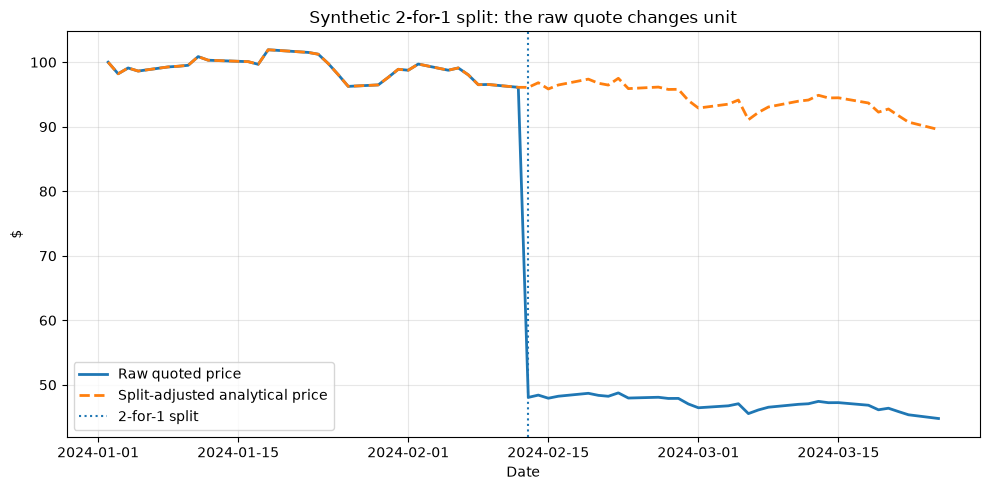

In [225]:
split_date = df.loc[SPLIT_INDEX, "date"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    df["date"],
    df["raw_price"],
    label="Raw quoted price",
    linewidth=2,
)
ax.plot(
    df["date"],
    df["split_adjusted_price"],
    label="Split-adjusted analytical price",
    linestyle="--",
    linewidth=2,
)
ax.axvline(
    split_date,
    linestyle=":",
    label="2-for-1 split",
)
ax.set_title(
    "Synthetic 2-for-1 split: the raw quote changes unit"
)
ax.set_xlabel("Date")
ax.set_ylabel("$")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

price_figure_path = (
    figure_dir
    / "synthetic_split_price_forensics.png"
)
fig.savefig(
    price_figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## False return

The raw series reports a $-50\%$ observation at the split, while the action-aware series records the correct zero economic return.

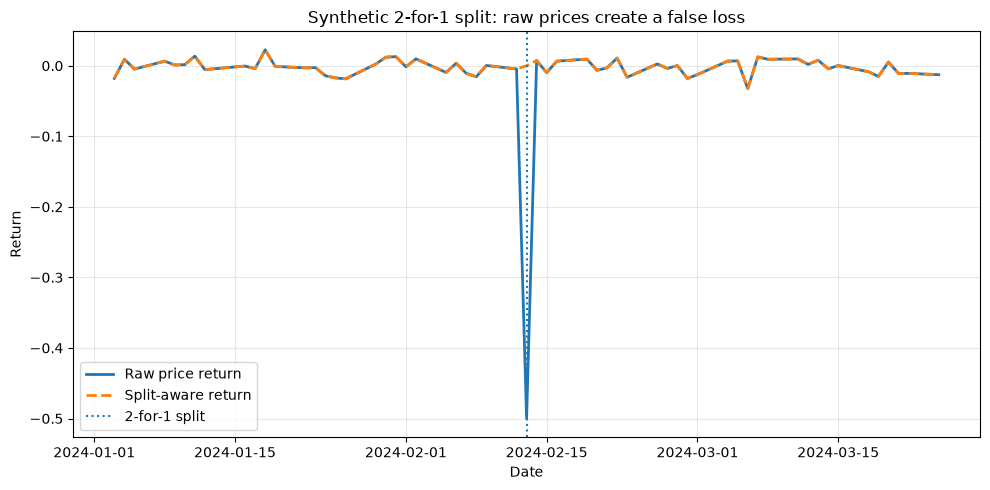

In [226]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    df["date"],
    df["raw_simple_return"],
    label="Raw price return",
    linewidth=2,
)
ax.plot(
    df["date"],
    df["split_aware_return"],
    label="Split-aware return",
    linestyle="--",
    linewidth=2,
)
ax.axvline(
    split_date,
    linestyle=":",
    label="2-for-1 split",
)

ax.set_title(
    "Synthetic 2-for-1 split: raw prices create a false loss"
)
ax.set_xlabel("Date")
ax.set_ylabel("Return")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

return_figure_path = (
    figure_dir
    / "synthetic_split_return_forensics.png"
)
fig.savefig(
    return_figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Persistence in rolling volatility

The split error remains in the trailing 20-return window after the event date, making the contamination persistent rather than instantaneous.

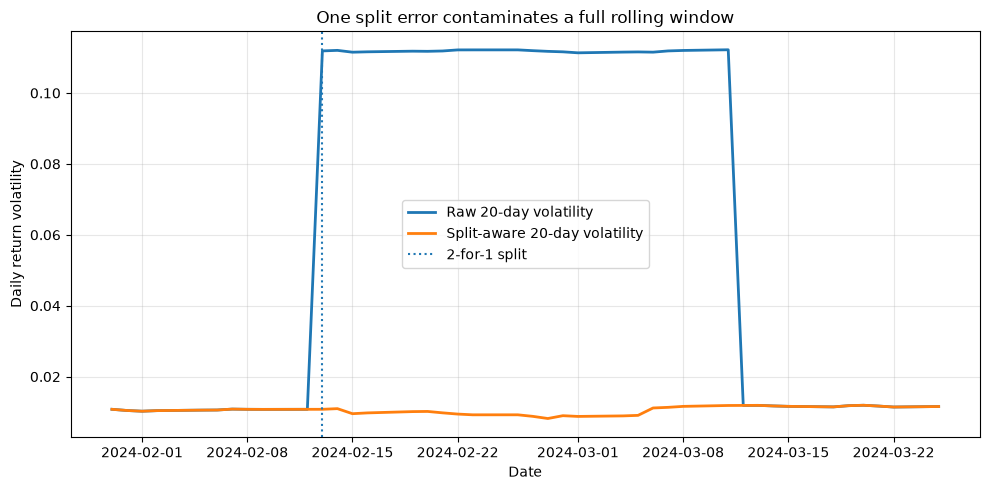

In [227]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    df["date"],
    df["raw_volatility_20d"],
    label="Raw 20-day volatility",
    linewidth=2,
)
ax.plot(
    df["date"],
    df["split_aware_volatility_20d"],
    label="Split-aware 20-day volatility",
    linewidth=2,
)
ax.axvline(
    split_date,
    linestyle=":",
    label="2-for-1 split",
)
ax.set_title(
    "One split error contaminates a full rolling window"
)
ax.set_xlabel("Date")
ax.set_ylabel("Daily return volatility")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

volatility_figure_path = (
    figure_dir
    / "synthetic_split_volatility_forensics.png"
)
fig.savefig(
    volatility_figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()


# 10. Conclusions and limitations

## Experiment A conclusion

A pure 2-for-1 stock split changes the unit in which price per share is quoted but, leaves investor wealth unchanged. Treating the mechanical price change as an ordinary return creates a false $-50\%$ observation that contaminates rolling volatility, anomaly diagnostics, moving-average indicators, and supervised-learning data. In the regression experiment, the same error appears first as a target and then as the next observation's lagged feature. Those two rows dominate the contaminated model's squared error. Robust scaling makes the feature center and scale less sensitive to the outlier, but it cannot repair a false economic target. After removing the two event-related rows before fitting, the raw and action-aware datasets produce identical models, confirming that corporate-action treatment is the sole cause of the observed distortion.

## Limitations

- The split is synthetic and deliberately isolated from any same-day market movement
- The weekday index is not an exchange calendar
- The regression is fitted and evaluated in sample because the objective is contamination diagnosis, not forecasting performance
- The split-adjusted price is an analytical wealth series, not an executable historical quote
- Real vendor adjustment factors may incorporate splits, dividends, and other actions using different conventions